# exp_003 — Context × quantization interaction

This notebook only reads verified artifacts; it never runs inference or fills missing cells. An explicit `EXP003_PHASE=pilot` or `main` is fail-closed when its manifest is absent. An unqualified run audits the committed legacy smoke artifact so the notebook remains executable, but that artifact uses the old catalog/scorer and is exploratory only.

The interaction label is descriptive: `approximately_constant`, `context_dependent`, or `insufficient_data`. The context × quantization and position × context comparisons use synthetic catalog tasks as a controlled retrieval stress test, not a general reasoning benchmark.

In [1]:
import csv
import hashlib
import json
import os
import runpy
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / 'src').is_dir() and (candidate / 'experiments').is_dir())
EXPERIMENT_ROOT = ROOT / 'experiments/exp_003-context_x_quantization'
sys.path.insert(0, str(ROOT / 'src'))
from llm_lab.analysis import (
    aggregate_jsonl,  # validation is centralized by analyze.py
    effective_context_by_variant_and_task,
    interaction_report,
    matched_cell_rows,
    relative_degradation_rows,
    task_level_wilson,
)

# Change PHASE to 'pilot' or 'main' for a calibrated measured phase. PHASE = 'smoke' is a legacy audit only.
REQUESTED_PHASE = os.environ.get('EXP003_PHASE', 'main')
PHASE = REQUESTED_PHASE
RESULTS_DIR = Path(os.environ.get('EXP003_RESULTS_DIR', ROOT / 'experiments/exp_003-context_x_quantization/results'))
if 'EXP003_PHASE' not in os.environ:
    for candidate_phase in ('main', 'pilot', 'smoke'):
        if (RESULTS_DIR / 'manifests' / f'{candidate_phase}.json').is_file():
            PHASE = candidate_phase
            break
ALLOW_FIXTURE = os.environ.get('EXP003_ALLOW_FIXTURE', '0') == '1'
if ALLOW_FIXTURE and PHASE != 'smoke':
    raise ValueError('EXP003_ALLOW_FIXTURE=1 is permitted only for PHASE=smoke')
RAW_PATH = RESULTS_DIR / 'raw' / f'{PHASE}-trials.jsonl'
SUMMARY_FILENAME = 'smoke-summary.csv' if PHASE == 'smoke' else ('summary.csv' if PHASE in {'main', 'pilot'} else f'{PHASE}-summary.csv')
SUMMARY_PATH = RESULTS_DIR / 'processed' / SUMMARY_FILENAME
MANIFEST_PATH = RESULTS_DIR / 'manifests' / f'{PHASE}.json'
FINDINGS_PATH = ROOT / 'docs/findings.md'
analysis_ready = MANIFEST_PATH.is_file()
legacy_smoke = False
if not analysis_ready:
    if 'EXP003_PHASE' in os.environ:
        raise FileNotFoundError(f'required {PHASE} manifest is missing: {MANIFEST_PATH}')
    print(f'exp_003 {PHASE} results are not available: {MANIFEST_PATH}')
    print('Run the exp_003 runner first, then rerun this notebook.')
else:
    run_manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
    raw_reference = run_manifest.get('raw_results')
    expected_raw_sha256 = run_manifest.get('raw_results_sha256')
    if not isinstance(raw_reference, str) or not isinstance(expected_raw_sha256, str):
        raise ValueError('run manifest must include raw_results and raw_results_sha256')
    raw_file = Path(raw_reference)
    if not raw_file.is_absolute():
        repo_relative = ROOT / raw_file
        manifest_relative = MANIFEST_PATH.parent / raw_file
        raw_file = repo_relative if repo_relative.is_file() else manifest_relative
    if not raw_file.is_file():
        raise FileNotFoundError(f'raw results are missing: {raw_file}')
    raw_digest = hashlib.sha256()
    with raw_file.open('rb') as raw_handle:
        for chunk in iter(lambda: raw_handle.read(1024 * 1024), b''):
            raw_digest.update(chunk)
    if raw_digest.hexdigest() != expected_raw_sha256:
        raise ValueError(f'raw results SHA-256 mismatch: expected {expected_raw_sha256}, found {raw_digest.hexdigest()}')
    legacy_smoke = PHASE == 'smoke' and run_manifest.get('scorer_version') != 'calibrated.v1'
    if legacy_smoke:
        if not SUMMARY_PATH.is_file():
            raise FileNotFoundError(f'legacy smoke summary is required: {SUMMARY_PATH}')
        summary_rows = pd.read_csv(SUMMARY_PATH).to_dict('records')
        for row in summary_rows:
            # Legacy v001 summaries predate task_id; recover it only for this audit.
            row.setdefault('task_id', str(row.get('context_instance_id', '')).split(':seed', 1)[0])
        print({'phase': PHASE, 'status': 'legacy exploratory audit', 'scorer_version': run_manifest.get('scorer_version', 'expected.v1'), 'trial_n': run_manifest.get('actual_trial_n'), 'note': 'not a Qwen measurement'})
    else:
        spec_path = EXPERIMENT_ROOT / 'analyze.py'
        namespace = runpy.run_path(str(spec_path), run_name='exp_003_analysis')
        regenerate = namespace['regenerate']
        regeneration = regenerate(MANIFEST_PATH, allow_fixture=ALLOW_FIXTURE)
        summary_rows = regeneration['summary_rows']
        if not SUMMARY_PATH.is_file():
            raise FileNotFoundError(f'processed summary is required: {SUMMARY_PATH}')
        print({'phase': PHASE, 'status': 'calibrated measured artifact', 'scorer_version': run_manifest.get('scorer_version'), 'trial_n': regeneration['trial_n'], 'summary_rows': len(summary_rows)})
    declared_lengths = tuple(run_manifest.get('context_lengths', ()))
    declared_positions = tuple(run_manifest.get('evidence_positions', ()))
    task_ids_for_gate = tuple(run_manifest.get('task_ids', ()))
    task_family_counts = {
        'literal_retrieval': sum('.literal.' in task_id for task_id in task_ids_for_gate),
        'semantic_retrieval': sum('.semantic.' in task_id for task_id in task_ids_for_gate),
        'multi_hop': sum('.multihop.' in task_id for task_id in task_ids_for_gate),
    }
    claim_blockers = []
    if PHASE != 'main': claim_blockers.append('main phase is required for a quantization interaction conclusion')
    if legacy_smoke: claim_blockers.append('legacy expected.v1 smoke is exploratory only')
    if run_manifest.get('scorer_version') != 'calibrated.v1': claim_blockers.append('scorer version must be calibrated.v1')
    if run_manifest.get('backend') != 'llama.cpp': claim_blockers.append('llama.cpp is the operational reference backend')
    if declared_lengths != (8192, 32768, 65536, 131072): claim_blockers.append('required context lengths are incomplete')
    if declared_positions != (0.05, 0.25, 0.5, 0.75, 0.95): claim_blockers.append('required evidence positions are incomplete')
    if len(task_ids_for_gate) < 30: claim_blockers.append('the calibrated catalog requires at least 30 independent tasks')
    if any(count < 10 for count in task_family_counts.values()): claim_blockers.append('each task family needs at least 10 independent tasks')
    if not {'q8_0', 'q4_k_m'}.issubset(set(item['condition_id'] for item in run_manifest.get('quantization_variants', []))): claim_blockers.append('Q8_0 and Q4_K_M are required comparison variants')
    if int(run_manifest.get('capability_repeats', run_manifest.get('repeats', 0))) != 1: claim_blockers.append('capability conclusions require one run per independent task')
    claim_ready = not claim_blockers
    print({'claim_ready': claim_ready, 'claim_blockers': claim_blockers})


{'phase': 'smoke', 'status': 'legacy exploratory audit', 'scorer_version': 'expected.v1', 'trial_n': 48, 'note': 'not a Qwen measurement'}
{'claim_ready': False, 'claim_blockers': ['main phase is required for a quantization interaction conclusion', 'legacy expected.v1 smoke is exploratory only', 'scorer version must be calibrated.v1', 'required context lengths are incomplete', 'required evidence positions are incomplete', 'the calibrated catalog requires at least 30 independent tasks', 'each task family needs at least 10 independent tasks']}


In [2]:
if analysis_ready:
    variant_ids = tuple(item['condition_id'] for item in run_manifest['quantization_variants'])
    context_lengths = tuple(run_manifest['context_lengths'])
    evidence_positions = tuple(run_manifest['evidence_positions'])
    task_types = tuple(run_manifest['task_types'])
    task_ids = tuple(run_manifest['task_ids'])
    task_types_by_id = {task_id: ('literal_retrieval' if '.literal.' in task_id else 'semantic_retrieval' if '.semantic.' in task_id else 'multi_hop') for task_id in task_ids}
    matched = matched_cell_rows(summary_rows, variant_ids=variant_ids, context_lengths=context_lengths, evidence_positions=evidence_positions, task_types=task_types, task_ids=task_ids, task_types_by_id=task_types_by_id)
    degradation = relative_degradation_rows(matched, baseline_context_tokens=min(context_lengths))
    gap_reports = interaction_report(matched, reference_variant=run_manifest.get('analysis', {}).get('primary_gap_reference', variant_ids[0]), approx_constant_gap_tolerance=float(run_manifest.get('analysis', {}).get('approx_constant_gap_tolerance', 0.10)))
    gap_report_frame = pd.DataFrame(gap_reports)
    if legacy_smoke:
        gap_report_frame['classification'] = 'insufficient_data'
        gap_report_frame['classification_reason'] = 'legacy expected.v1 smoke; one task per family and no calibrated scorer'
    display(gap_report_frame[['task_type', 'variant_condition_id', 'metric', 'classification', 'gap_change', 'matched_n']])
    metric_columns = {'exact_accuracy', 'answer_bearing_accuracy', 'format_validity'}
    calibrated_metric_fields = {'exact_correct_n', 'answer_bearing_correct_n', 'format_valid_n'}
    if calibrated_metric_fields.issubset(pd.DataFrame(matched).columns):
        task_uncertainty = task_level_wilson(
            matched,
            group_keys=('variant_condition_id', 'task_type', 'target_context_tokens', 'requested_evidence_position'),
            metric_fields={'end_to_end': 'correct_n', 'exact': 'exact_correct_n', 'answer_bearing': 'answer_bearing_correct_n', 'format_valid': 'format_valid_n'},
        )
        display(pd.DataFrame(task_uncertainty))
        print('Wilson intervals use independent task IDs; runtime/invalid-output attempts remain in the denominator.')
    else:
        task_uncertainty = []
    if metric_columns.issubset(pd.DataFrame(summary_rows).columns):
        metric_summary = pd.DataFrame(summary_rows).groupby(['variant_condition_id', 'task_type', 'target_context_tokens'], as_index=False).agg(attempted_n=('attempted_n', 'sum'), end_to_end_success=('end_to_end_success', 'mean'), exact_accuracy=('exact_accuracy', 'mean'), answer_bearing_accuracy=('answer_bearing_accuracy', 'mean'), format_validity=('format_validity', 'mean'))
        display(metric_summary)
    else:
        print('Calibrated exact/answer-bearing/format metrics are unavailable in this legacy artifact.')
    if legacy_smoke:
        print('Legacy smoke has one old task per family and no calibrated scorer; interaction is insufficient_data and cannot update docs/findings.md.')

,task_type,variant_condition_id,metric,classification,gap_change,matched_n
0,literal_retrieval,q4_k_m,end_to_end_success,insufficient_data,0.0,4
1,literal_retrieval,q5_k_m,end_to_end_success,insufficient_data,0.0,4
2,literal_retrieval,q6_k,end_to_end_success,insufficient_data,0.0,4
3,multi_hop,q4_k_m,end_to_end_success,insufficient_data,0.0,4
4,multi_hop,q5_k_m,end_to_end_success,insufficient_data,0.0,4
5,multi_hop,q6_k,end_to_end_success,insufficient_data,0.0,4
6,semantic_retrieval,q4_k_m,end_to_end_success,insufficient_data,0.0,4
7,semantic_retrieval,q5_k_m,end_to_end_success,insufficient_data,0.0,4
8,semantic_retrieval,q6_k,end_to_end_success,insufficient_data,0.0,4


Calibrated exact/answer-bearing/format metrics are unavailable in this legacy artifact.
Legacy smoke has one old task per family and no calibrated scorer; interaction is insufficient_data and cannot update docs/findings.md.


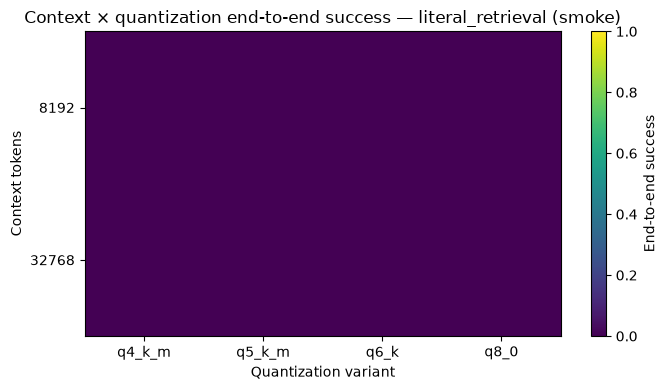

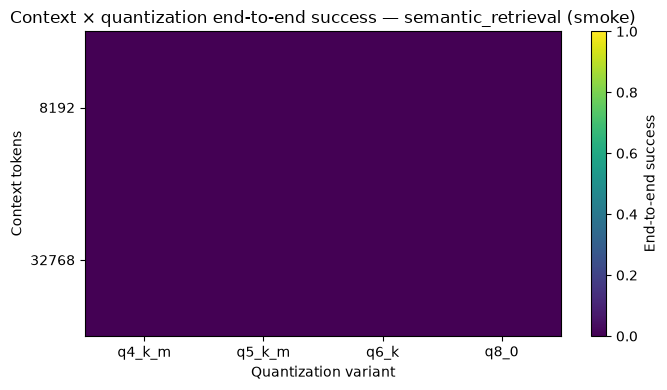

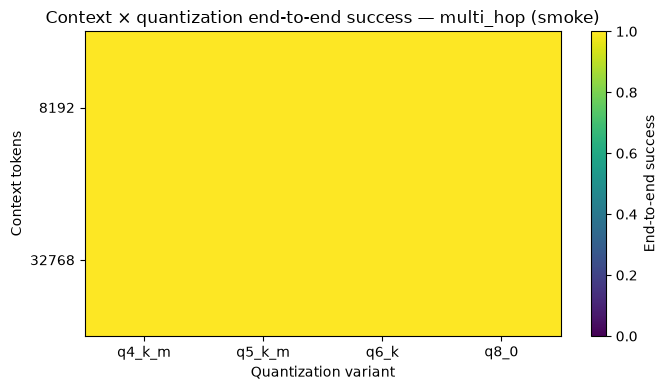

In [3]:
if analysis_ready:
    FIGURES_DIR = RESULTS_DIR / 'figures'
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    matched_frame = pd.DataFrame(matched)
    for task_type in task_types:
        plot_frame = matched_frame[matched_frame['task_type'] == task_type]
        heatmap = plot_frame.groupby(['target_context_tokens', 'variant_condition_id'], as_index=False)['end_to_end_success'].mean().pivot(index='target_context_tokens', columns='variant_condition_id', values='end_to_end_success')
        figure, axis = plt.subplots(figsize=(7, 4))
        image = axis.imshow(heatmap.to_numpy(dtype=float), vmin=0, vmax=1, aspect='auto', cmap='viridis')
        axis.set_title(f'Context × quantization end-to-end success — {task_type} ({PHASE})')
        axis.set_xlabel('Quantization variant')
        axis.set_ylabel('Context tokens')
        axis.set_xticks(range(len(heatmap.columns)), heatmap.columns)
        axis.set_yticks(range(len(heatmap.index)), heatmap.index)
        figure.colorbar(image, ax=axis, label='End-to-end success')
        figure.tight_layout()
        figure.savefig(FIGURES_DIR / f'context-x-quantization-{task_type}.png', dpi=160)
        plt.show()

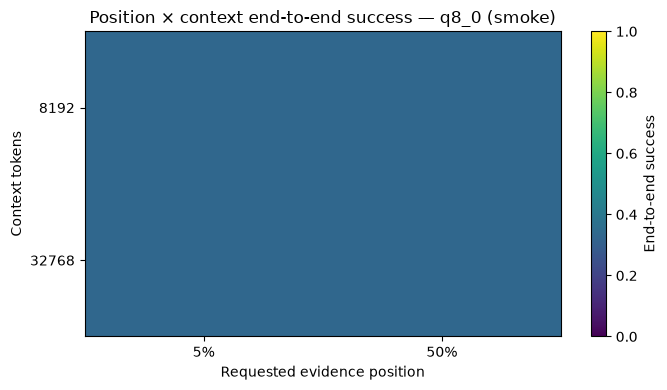

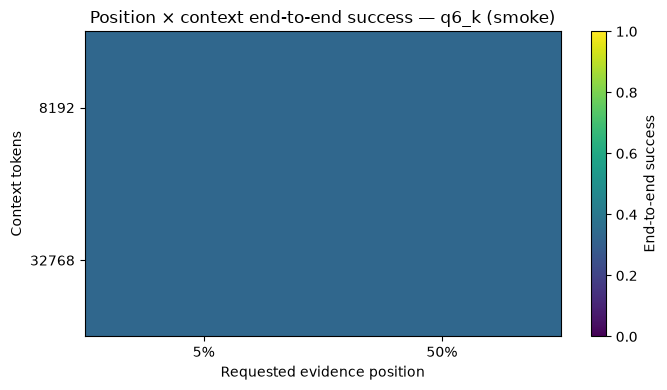

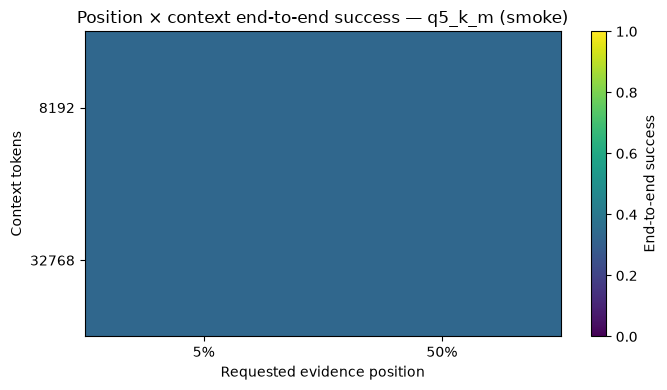

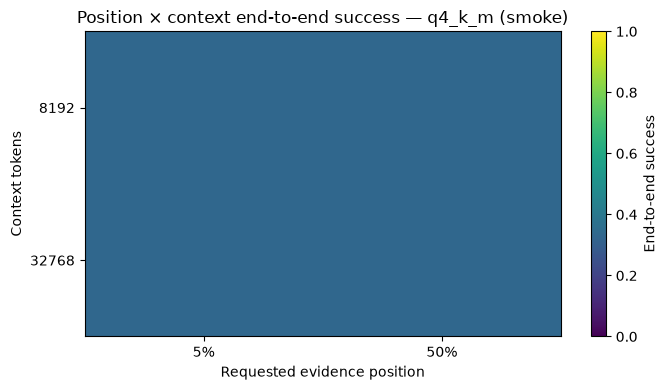

In [4]:
if analysis_ready:
    for variant_id in variant_ids:
        plot_frame = matched_frame[matched_frame['variant_condition_id'] == variant_id]
        heatmap = plot_frame.groupby(['target_context_tokens', 'requested_evidence_position'], as_index=False)['end_to_end_success'].mean().pivot(index='target_context_tokens', columns='requested_evidence_position', values='end_to_end_success')
        figure, axis = plt.subplots(figsize=(7, 4))
        image = axis.imshow(heatmap.to_numpy(dtype=float), vmin=0, vmax=1, aspect='auto', cmap='viridis')
        axis.set_title(f'Position × context end-to-end success — {variant_id} ({PHASE})')
        axis.set_xlabel('Requested evidence position')
        axis.set_ylabel('Context tokens')
        axis.set_xticks(range(len(heatmap.columns)), [f'{value:.0%}' for value in heatmap.columns])
        axis.set_yticks(range(len(heatmap.index)), heatmap.index)
        figure.colorbar(image, ax=axis, label='End-to-end success')
        figure.tight_layout()
        figure.savefig(FIGURES_DIR / f'position-x-context-{variant_id}.png', dpi=160)
        plt.show()

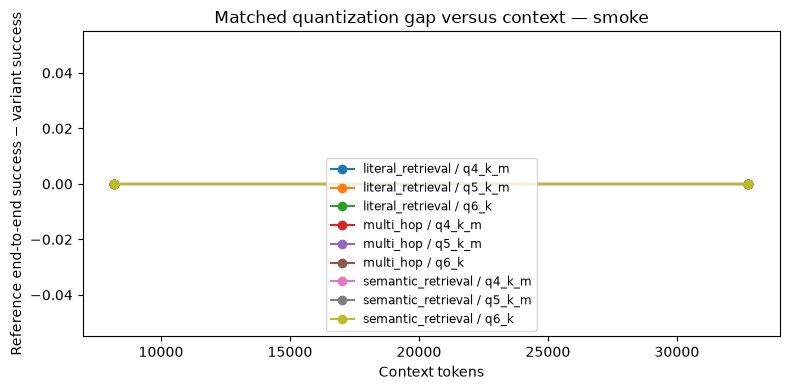

,task_type,variant_condition_id,classification,shortest_context_gap,largest_context_gap,gap_change
0,literal_retrieval,q4_k_m,insufficient_data,0.0,0.0,0.0
1,literal_retrieval,q5_k_m,insufficient_data,0.0,0.0,0.0
2,literal_retrieval,q6_k,insufficient_data,0.0,0.0,0.0
3,multi_hop,q4_k_m,insufficient_data,0.0,0.0,0.0
4,multi_hop,q5_k_m,insufficient_data,0.0,0.0,0.0
5,multi_hop,q6_k,insufficient_data,0.0,0.0,0.0
6,semantic_retrieval,q4_k_m,insufficient_data,0.0,0.0,0.0
7,semantic_retrieval,q5_k_m,insufficient_data,0.0,0.0,0.0
8,semantic_retrieval,q6_k,insufficient_data,0.0,0.0,0.0


In [5]:
if analysis_ready:
    # analyze.py writes relative-degradation.csv and interaction.json.
    gap_points = [dict(task_type=report['task_type'], variant_condition_id=report['variant_condition_id'], **point) for report in gap_reports for point in report['context_points']]
    gap_points_frame = pd.DataFrame(gap_points)
    figure, axis = plt.subplots(figsize=(8, 4))
    for (task_type, variant_id), group in gap_points_frame.groupby(['task_type', 'variant_condition_id']):
        axis.plot(group['context_tokens'], group['quantization_gap'], marker='o', label=f'{task_type} / {variant_id}')
    axis.set_title(f'Matched quantization gap versus context — {PHASE}')
    axis.set_xlabel('Context tokens')
    axis.set_ylabel('Reference end-to-end success − variant success')
    axis.legend(fontsize='small')
    figure.tight_layout()
    figure.savefig(FIGURES_DIR / 'quantization-gap-vs-context.png', dpi=160)
    plt.show()
    display(gap_report_frame[['task_type', 'variant_condition_id', 'classification', 'shortest_context_gap', 'largest_context_gap', 'gap_change']])

In [6]:
if analysis_ready:
    effective = effective_context_by_variant_and_task(matched, baseline_context_tokens=min(context_lengths), alpha=float(run_manifest.get('effective_context', {}).get('alpha', 0.90)), minimum_baseline_accuracy=float(run_manifest.get('effective_context', {}).get('baseline_accuracy_gate', 0.80)))
    effective_frame = pd.DataFrame(effective)
    display(effective_frame[['variant_condition_id', 'task_type', 'status', 'effective_context_tokens', 'crossing_context_tokens']])
    display(pd.DataFrame(degradation)[['task_id', 'variant_condition_id', 'target_context_tokens', 'accuracy_degradation', 'relative_degradation']])
    if legacy_smoke:
        print('Legacy smoke is not calibrated and is not a Qwen measurement; no finding is added to docs/findings.md.')
    elif 'exp_003: not yet measured' in FINDINGS_PATH.read_text(encoding='utf-8'):
        print('exp_003 is not yet measured; no finding is added from this notebook run.')
    else:
        print('Only reviewed real-model data may update docs/findings.md.')

,variant_condition_id,task_type,status,effective_context_tokens,crossing_context_tokens
0,q4_k_m,literal_retrieval,baseline_limited,None,None
1,q4_k_m,multi_hop,right_censored,None,None
2,q4_k_m,semantic_retrieval,baseline_limited,None,None
3,q5_k_m,literal_retrieval,baseline_limited,None,None
4,q5_k_m,multi_hop,right_censored,None,None
5,q5_k_m,semantic_retrieval,baseline_limited,None,None
6,q6_k,literal_retrieval,baseline_limited,None,None
7,q6_k,multi_hop,right_censored,None,None
8,q6_k,semantic_retrieval,baseline_limited,None,None
9,q8_0,literal_retrieval,baseline_limited,None,None


,task_id,variant_condition_id,target_context_tokens,accuracy_degradation,relative_degradation
0,task.literal.000001,q4_k_m,8192,0.0,NaN
1,task.literal.000001,q4_k_m,8192,0.0,NaN
2,task.literal.000001,q4_k_m,32768,0.0,NaN
3,task.literal.000001,q4_k_m,32768,0.0,NaN
4,task.multihop.000001,q4_k_m,8192,0.0,0.0
5,task.multihop.000001,q4_k_m,8192,0.0,0.0
6,task.multihop.000001,q4_k_m,32768,0.0,0.0
7,task.multihop.000001,q4_k_m,32768,0.0,0.0
8,task.semantic.000001,q4_k_m,8192,0.0,NaN
9,task.semantic.000001,q4_k_m,8192,0.0,NaN


Legacy smoke is not calibrated and is not a Qwen measurement; no finding is added to docs/findings.md.
